Name: Tanvi Gajanan Upganlawar

Roll no: 12

PRN no: 1252090012


---



Assignment 13

 Implement K-Means clustering on Iris.csv dataset. Determine the number of clusters using the elbow method. Dataset Link: https://www.kaggle.com/datasets/uciml/iris

In [ ]:
import pandas as pd

# Load dataset
dataset = pd.read_csv('Iris.csv')

print(dataset.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


Data preprocessing

In [ ]:

dataset = dataset.drop('Id', axis=1)

print(dataset.isnull().sum())

dataset.fillna(dataset.mean(numeric_only=True), inplace=True)

X = dataset.drop('Species', axis=1)

print(X.head())

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2


Feature scaling

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Elbow method

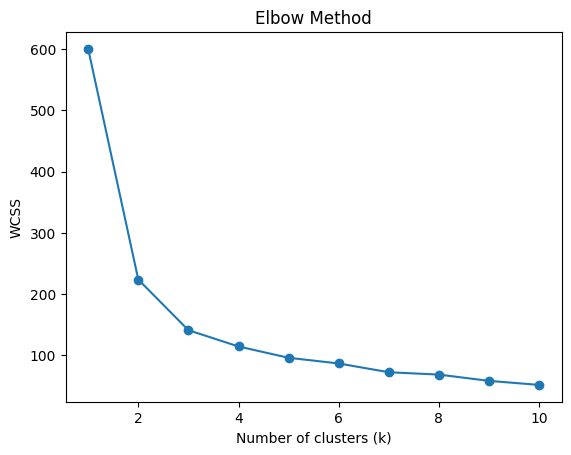

In [ ]:

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

k-means

In [ ]:

kmeans = KMeans(n_clusters=3, random_state=0)
y_kmeans = kmeans.fit_predict(X_scaled)

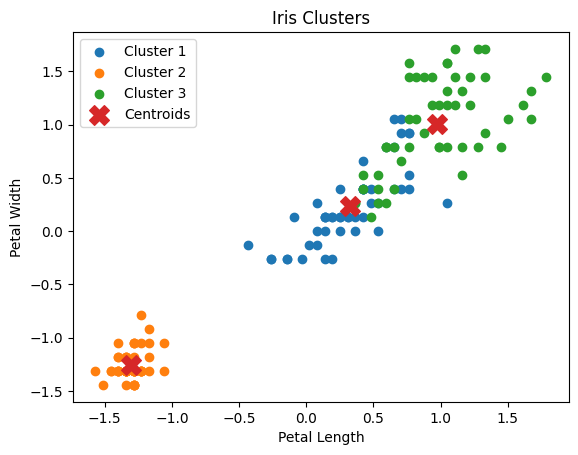

In [ ]:

plt.scatter(X_scaled[y_kmeans == 0, 2], X_scaled[y_kmeans == 0, 3], label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 2], X_scaled[y_kmeans == 1, 3], label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 2], X_scaled[y_kmeans == 2, 3], label='Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3],
            s=200, marker='X', label='Centroids')

plt.title('Iris Clusters')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.4556692449110409
